# Purpose Option Detection – Production Pipeline

## Problem Statement
Given scanned form images containing five options: **Revenue / Training / Test / Ferry / Others**, detect which option has been hand-marked (via check marks, circles, crosses, strikethroughs, or no mark at all) and return a single classification label.

## Approach – Two-Stage Pipeline

### Stage 1: YOLO Object Detection
We train a **YOLOv11n** object detection model on the Roboflow-annotated dataset that has **2 classes**:
- **`check`** (class 0): a hand-drawn mark (tick, circle, cross, underline, etc.) localized around a specific option.
- **`nan`** (class 1): a large bounding box spanning the entire row, indicating *no option was selected*.

This stage handles the *variety* of marking styles: YOLO learns to localize the mark regardless of whether it's a circle, tick, cross-out, etc.

### Stage 2: Position-Based Classification
Once the check mark bounding box is detected, we use the **x-center** of the box to map it to one of the five options. The options are arranged horizontally in a fixed layout:

| Option   | x-range (normalized) | Cluster center |
|----------|---------------------|----------------|
| Revenue  | 0.00 – 0.28         | ~0.15          |
| Training | 0.28 – 0.47         | ~0.39          |
| Test     | 0.47 – 0.62         | ~0.55          |
| Ferry    | 0.62 – 0.77         | ~0.70          |
| Others   | 0.77 – 1.00         | ~0.85          |

### Edge Cases Handled
- **No detection** → `None` (no option selected)
- **`nan` class detected** → `None`
- **Multiple `check` boxes** → choose the one with highest confidence
- **Two options marked** → report highest-confidence detection

### Why This Works
- YOLO is robust to varied mark styles (circles, ticks, crosses) because it was trained on these variants.
- The position mapping is deterministic and calibrated from training data analysis.
- The two-stage approach separates *detection* from *classification*, making each stage independently debuggable.

## 1. Setup & Imports

In [1]:
import os
import glob
import random
import collections
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

# Paths
DATASET_ROOT = Path(r"c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)")
DATA_YAML = DATASET_ROOT / "data.yaml"
PRETRAINED_WEIGHTS = Path(r"c:\Users\ssingh49\OCR\yolo11n.pt")

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_LABELS = DATASET_ROOT / "train" / "labels"
VALID_IMAGES = DATASET_ROOT / "valid" / "images"
VALID_LABELS = DATASET_ROOT / "valid" / "labels"
TEST_IMAGES  = DATASET_ROOT / "test"  / "images"
TEST_LABELS  = DATASET_ROOT / "test"  / "labels"

CLASS_NAMES = {0: "check", 1: "nan"}

# Option mapping: x-center boundaries (normalized 0-1)
OPTION_BOUNDARIES = [
    (0.00, 0.28, "Revenue"),
    (0.28, 0.47, "Training"),
    (0.47, 0.62, "Test"),
    (0.62, 0.77, "Ferry"),
    (0.77, 1.01, "Others"),
]

print(f"Dataset root: {DATASET_ROOT}")
print(f"Train images: {len(list(TRAIN_IMAGES.glob('*.jpg')))}")
print(f"Valid images: {len(list(VALID_IMAGES.glob('*.jpg')))}")
print(f"Test images:  {len(list(TEST_IMAGES.glob('*.jpg')))}")

Dataset root: c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)
Train images: 2119
Valid images: 328
Test images:  318


## 2. Data Exploration

In [6]:
def parse_yolo_labels(label_dir):
    """Parse all YOLO label files and return list of (filename, class_id, cx, cy, w, h)."""
    records = []
    for f in sorted(Path(label_dir).glob("*.txt")):
        lines = f.read_text().strip().splitlines()
        if not lines or (len(lines) == 1 and not lines[0].strip()):
            records.append((f.stem, -1, 0, 0, 0, 0))  # empty = no annotation
            continue
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                records.append((f.stem, cls, cx, cy, w, h))
    return records

train_records = parse_yolo_labels(TRAIN_LABELS)

# Class distribution
class_counts = collections.Counter(r[1] for r in train_records)
print("Class distribution in training set:")
for cls, count in sorted(class_counts.items()):
    name = CLASS_NAMES.get(cls, "empty")
    print(f"  Class {cls} ({name}): {count}")

Class distribution in training set:
  Class -1 (empty): 4
  Class 0 (check): 2023
  Class 1 (nan): 219


In [7]:
def x_to_option(x_center):
    """Map normalized x-center to option name."""
    for lo, hi, name in OPTION_BOUNDARIES:
        if lo <= x_center < hi:
            return name
    return "Others"

# Analyze x-position distribution for 'check' class
check_records = [r for r in train_records if r[1] == 0]
x_values = [r[2] for r in check_records]

option_counts = collections.Counter(x_to_option(x) for x in x_values)
print("Option distribution (derived from check x-position):")
for opt in ["Revenue", "Training", "Test", "Ferry", "Others"]:
    print(f"  {opt}: {option_counts.get(opt, 0)}")

nan_count = sum(1 for r in train_records if r[1] == 1)
empty_count = sum(1 for r in train_records if r[1] == -1)
print(f"  None (nan class): {nan_count}")
print(f"  None (empty label): {empty_count}")

Option distribution (derived from check x-position):
  Revenue: 1914
  Training: 102
  Test: 2
  Ferry: 2
  Others: 3
  None (nan class): 219
  None (empty label): 4


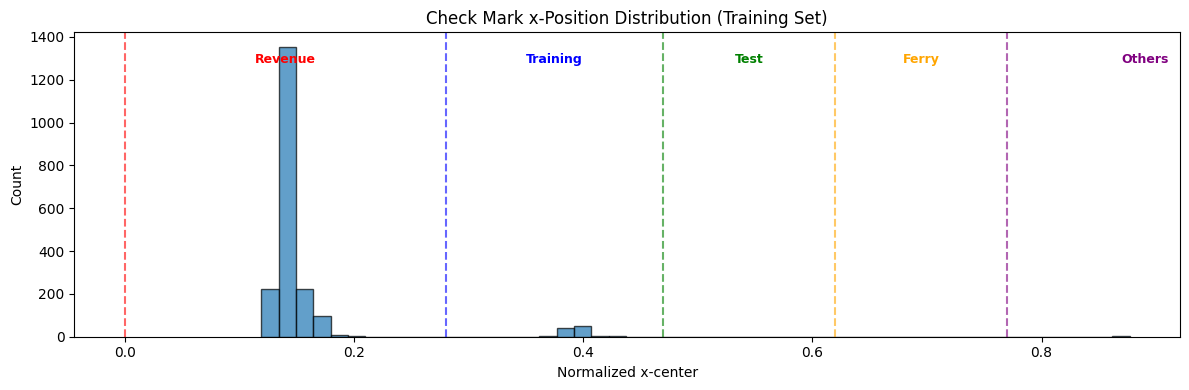

In [6]:
# Visualize x-position histogram
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.hist(x_values, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Normalized x-center")
ax.set_ylabel("Count")
ax.set_title("Check Mark x-Position Distribution (Training Set)")

# Draw option boundaries
colors = ["red", "blue", "green", "orange", "purple"]
for (lo, hi, name), color in zip(OPTION_BOUNDARIES, colors):
    ax.axvline(lo, color=color, linestyle="--", alpha=0.6)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.9, name, ha="center", fontsize=9, color=color, fontweight="bold")

plt.tight_layout()
plt.show()

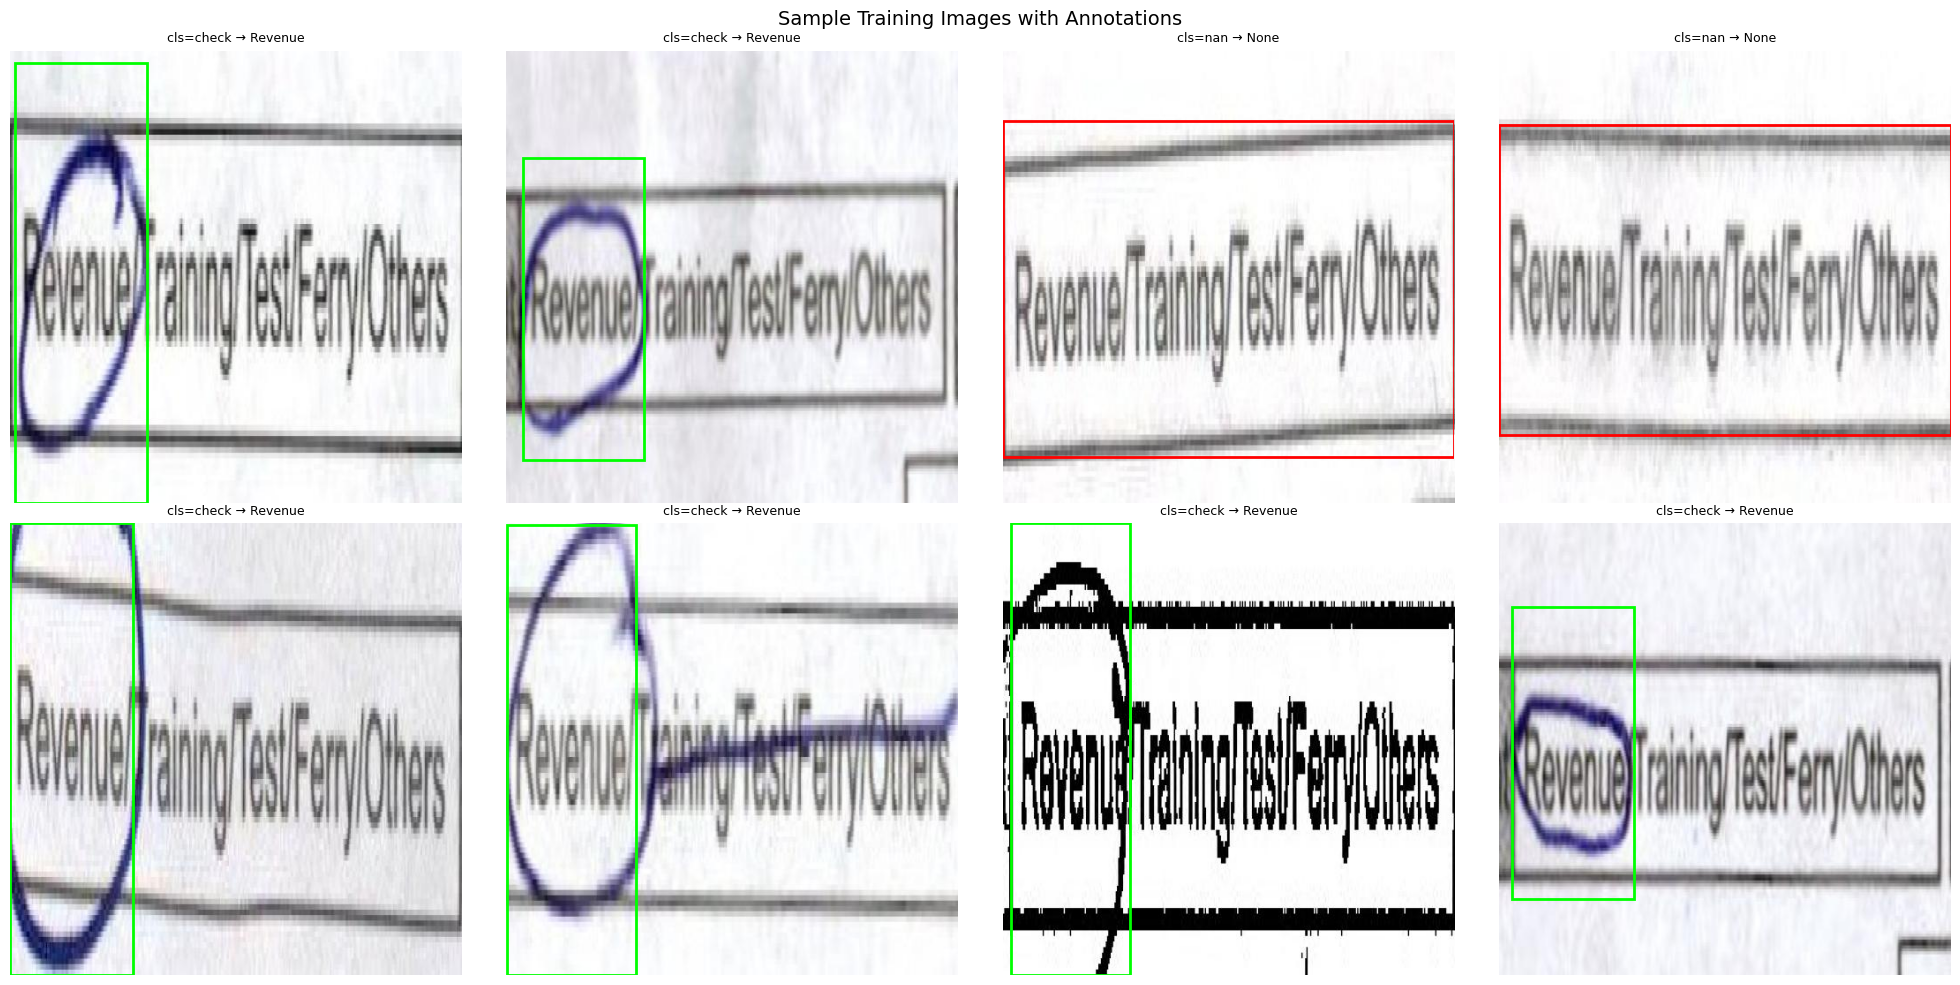

In [7]:
# Visualize sample images with annotations
def show_samples(image_dir, label_dir, n=8):
    """Show sample images with YOLO bounding boxes overlaid."""
    img_files = sorted(Path(image_dir).glob("*.jpg"))
    samples = random.sample(img_files, min(n, len(img_files)))

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, img_path in enumerate(samples):
        img = Image.open(img_path)
        w_img, h_img = img.size
        ax = axes[idx]
        ax.imshow(img)

        label_path = Path(label_dir) / (img_path.stem + ".txt")
        title = "No label"
        if label_path.exists():
            lines = label_path.read_text().strip().splitlines()
            if lines and lines[0].strip():
                for line in lines:
                    parts = line.strip().split()
                    cls = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    # Convert to pixel coordinates
                    x1 = (cx - bw / 2) * w_img
                    y1 = (cy - bh / 2) * h_img
                    rect = patches.Rectangle(
                        (x1, y1), bw * w_img, bh * h_img,
                        linewidth=2,
                        edgecolor="lime" if cls == 0 else "red",
                        facecolor="none"
                    )
                    ax.add_patch(rect)
                    option = x_to_option(cx) if cls == 0 else "None"
                    title = f"cls={CLASS_NAMES[cls]} → {option}"
            else:
                title = "Empty → None"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.suptitle("Sample Training Images with Annotations", fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_IMAGES, TRAIN_LABELS)

## 3. Fix Data YAML Paths
The Roboflow export uses relative paths that may not work. We create an absolute-path version.

In [2]:
fixed_yaml_path = DATASET_ROOT / "data_fixed.yaml"

yaml_content = f"""train: {TRAIN_IMAGES}
val: {VALID_IMAGES}
test: {TEST_IMAGES}

nc: 2
names: ['check', 'nan']
"""

fixed_yaml_path.write_text(yaml_content)
print(f"Written fixed YAML to: {fixed_yaml_path}")
print(fixed_yaml_path.read_text())

Written fixed YAML to: c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)\data_fixed.yaml
train: c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)\train\images
val: c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)\valid\images
test: c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)\test\images

nc: 2
names: ['check', 'nan']



## 4. Train YOLOv11n – Check Mark Detection

We fine-tune the pretrained `yolo11n.pt` on our dataset. Key training choices:
- **Small model (nano)**: fast inference for production, sufficient for this binary detection task.
- **Image size 512**: matches the Roboflow export resolution.
- **Augmentation**: YOLO's built-in augmentations (mosaic, flips, color jitter) help generalize across mark styles.
- **30 epochs**: sufficient for convergence on ~2100 training images with transfer learning.

In [9]:
# Load pretrained YOLOv11n
model = YOLO(str(PRETRAINED_WEIGHTS))

# Train
results = model.train(
    data=str(fixed_yaml_path),
    epochs=30,
    imgsz=512,
    batch=16,
    patience=10,            # early stopping
    save=True,
    project=str(Path(r"c:\Users\ssingh49\OCR\runs")),
    name="purpose_detection",
    exist_ok=True,
    verbose=True,
)

Ultralytics 8.4.24  Python-3.13.9 torch-2.10.0+cpu CPU (AMD Ryzen 7 PRO 8840U w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)\data_fixed.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\ssingh49\OCR\yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=purpose_detection, nbs=64, nms=False

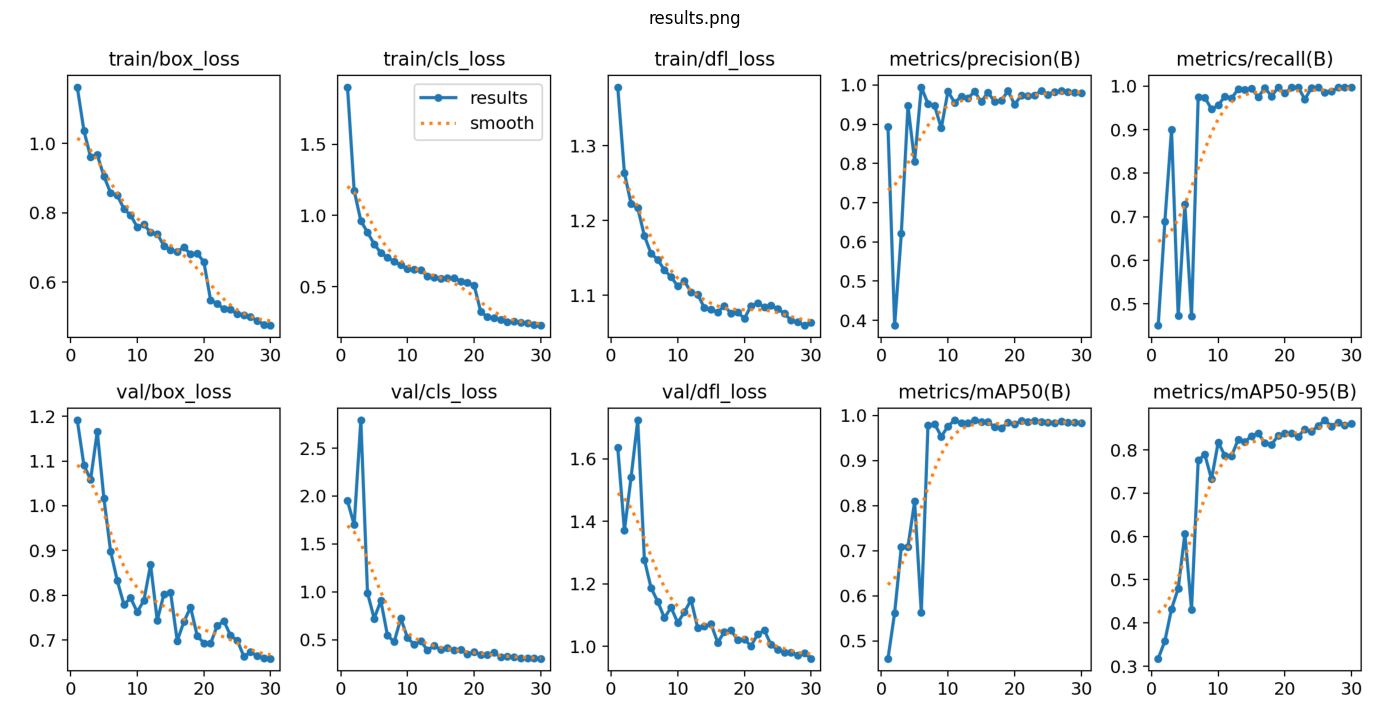

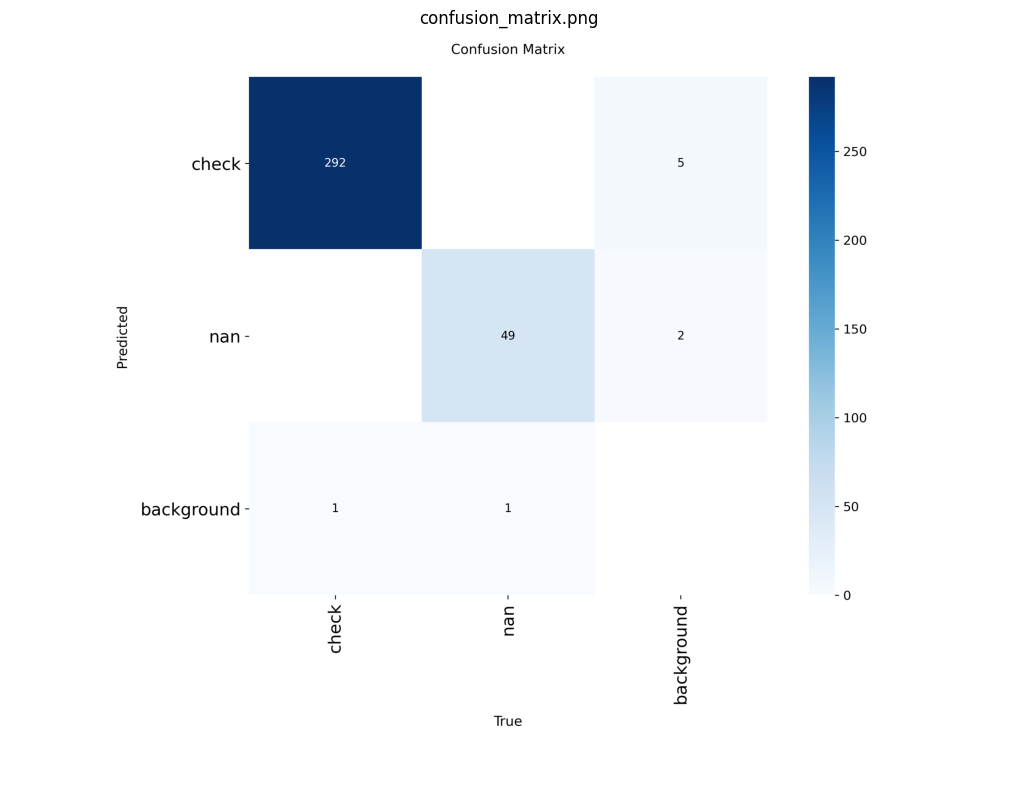

val_batch0_pred.png not found


In [10]:
# Display training results
results_dir = Path(r"c:\Users\ssingh49\OCR\runs\purpose_detection")

# Show training curves if available
for plot_name in ["results.png", "confusion_matrix.png", "val_batch0_pred.png"]:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        img = Image.open(plot_path)
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.imshow(img)
        ax.set_title(plot_name)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{plot_name} not found")

## 5. Load Best Model & Define Inference Pipeline

In [4]:
# Load the best trained weights
results_dir = Path(r"c:\Users\ssingh49\OCR\runs\purpose_detection")
best_weights = results_dir / "weights" / "best.pt"
if best_weights.exists():
    detector = YOLO(str(best_weights))
    print(f"Loaded best model from: {best_weights}")
else:
    print("best.pt not found, using last.pt or re-check training output")
    last_weights = results_dir / "weights" / "last.pt"
    detector = YOLO(str(last_weights))

Loaded best model from: c:\Users\ssingh49\OCR\runs\purpose_detection\weights\best.pt


In [8]:
def predict_option(model, image_path, conf_threshold=0.25):
    """
    End-to-end prediction: image → selected option.

    Returns:
        dict with keys:
            - 'option': str – one of Revenue/Training/Test/Ferry/Others/None
            - 'confidence': float – detection confidence (0.0 if None)
            - 'bbox': tuple or None – (x1, y1, x2, y2) in pixels
            - 'x_center_norm': float – normalized x-center of detection
    """
    results = model(image_path, conf=conf_threshold, verbose=False)
    result = results[0]

    if result.boxes is None or len(result.boxes) == 0:
        return {"option": "None", "confidence": 0.0, "bbox": None, "x_center_norm": None}

    boxes = result.boxes
    classes = boxes.cls.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()
    xyxy = boxes.xyxy.cpu().numpy()

    # Filter for 'check' class (0) only
    check_mask = classes == 0
    if not check_mask.any():
        # Only 'nan' detections → None
        return {"option": "None", "confidence": float(confs.max()), "bbox": None, "x_center_norm": None}

    check_confs = confs[check_mask]
    check_xyxy = xyxy[check_mask]

    # Pick highest-confidence check detection
    best_idx = check_confs.argmax()
    best_conf = float(check_confs[best_idx])
    best_box = check_xyxy[best_idx]

    # Compute normalized x-center
    img_w = result.orig_shape[1]  # width
    x_center_px = (best_box[0] + best_box[2]) / 2
    x_center_norm = x_center_px / img_w

    option = x_to_option(x_center_norm)

    return {
        "option": option,
        "confidence": best_conf,
        "bbox": tuple(best_box.tolist()),
        "x_center_norm": float(x_center_norm),
    }


# Quick test
sample_img = next(TEST_IMAGES.glob("*.jpg"))
pred = predict_option(detector, str(sample_img))
print(f"Sample prediction: {pred}")

Sample prediction: {'option': 'Revenue', 'confidence': 0.8087897300720215, 'bbox': (17.971099853515625, 100.42677307128906, 148.09292602539062, 445.3424072265625), 'x_center_norm': 0.16217190027236938}


## 6. Evaluate on Test Set

In [9]:
def get_ground_truth_option(label_path):
    """Derive ground-truth option from YOLO label file."""
    if not label_path.exists():
        return "None"
    lines = label_path.read_text().strip().splitlines()
    if not lines or (len(lines) == 1 and not lines[0].strip()):
        return "None"

    # Find check (class 0) annotations
    check_boxes = []
    has_nan = False
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(parts[0])
        if cls == 0:
            check_boxes.append(float(parts[1]))
        elif cls == 1:
            has_nan = True

    if not check_boxes:
        return "None"

    # Use the first check box x-center (or could average for multi)
    return x_to_option(check_boxes[0])


# Evaluate all test images
test_images = sorted(TEST_IMAGES.glob("*.jpg"))
y_true = []
y_pred = []
results_log = []

for img_path in test_images:
    label_path = TEST_LABELS / (img_path.stem + ".txt")
    gt = get_ground_truth_option(label_path)
    pred = predict_option(detector, str(img_path))

    y_true.append(gt)
    y_pred.append(pred["option"])
    results_log.append({"image": img_path.name, "gt": gt, "pred": pred["option"], "conf": pred["confidence"]})

print(f"Evaluated {len(test_images)} test images")

Evaluated 318 test images



=== Classification Report ===
              precision    recall  f1-score   support

     Revenue       1.00      0.98      0.99       284
    Training       0.00      0.00      0.00         0
        None       1.00      1.00      1.00        34

    accuracy                           0.98       318
   macro avg       0.67      0.66      0.66       318
weighted avg       1.00      0.98      0.99       318



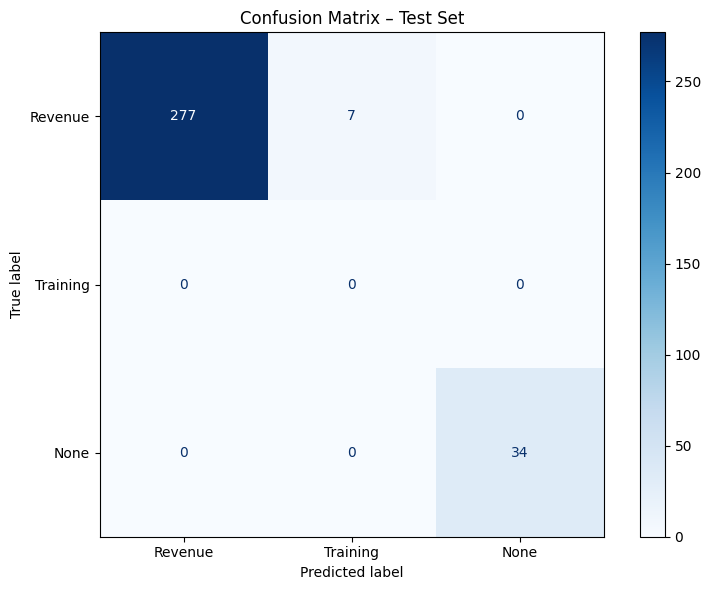


Overall Accuracy: 97.80%


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Classification report
labels = ["Revenue", "Training", "Test", "Ferry", "Others", "None"]
present_labels = sorted(set(y_true + y_pred), key=lambda x: labels.index(x) if x in labels else 99)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, labels=present_labels, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=present_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_labels)
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.show()

# Overall accuracy
accuracy = sum(1 for t, p in zip(y_true, y_pred) if t == p) / len(y_true)
print(f"\nOverall Accuracy: {accuracy:.2%}")

Misclassified: 7 / 318


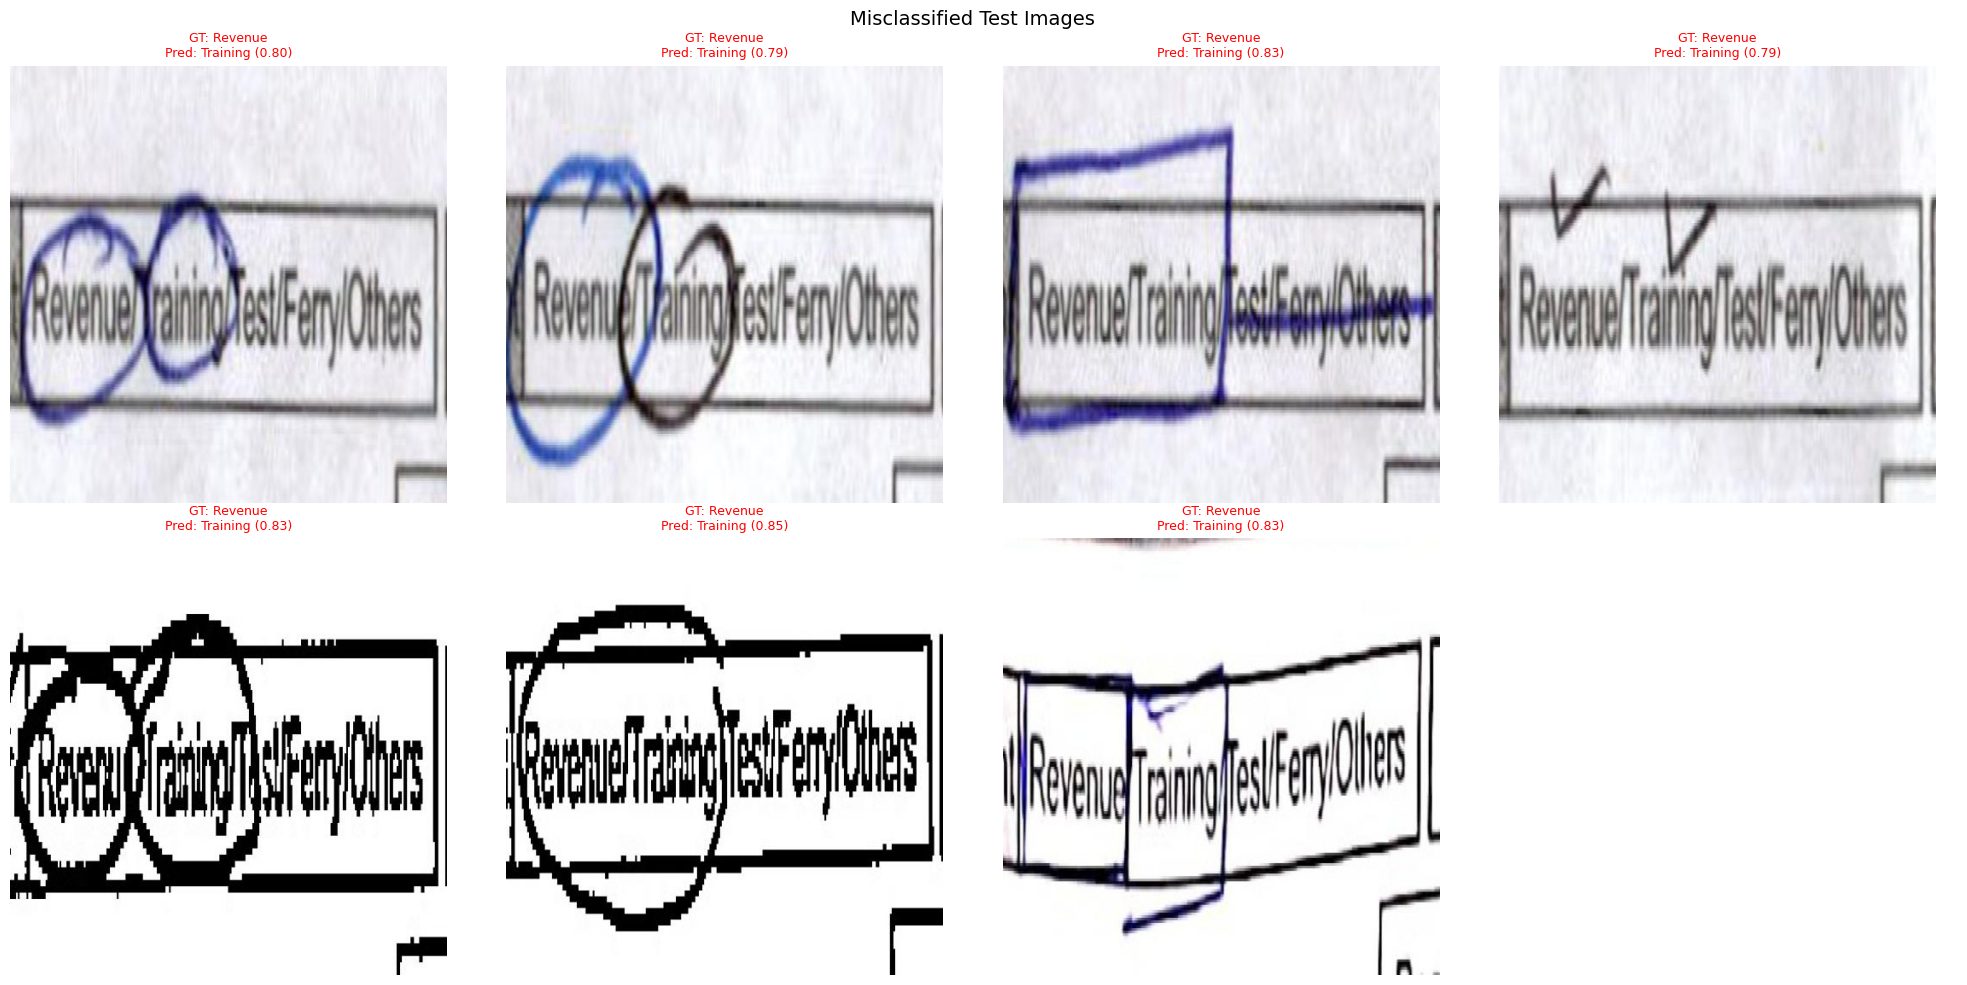

In [11]:
# Show misclassified examples
misclassified = [r for r in results_log if r["gt"] != r["pred"]]
print(f"Misclassified: {len(misclassified)} / {len(results_log)}")

if misclassified:
    n_show = min(8, len(misclassified))
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    for i, rec in enumerate(misclassified[:n_show]):
        img = Image.open(TEST_IMAGES / rec["image"])
        axes[i].imshow(img)
        axes[i].set_title(f"GT: {rec['gt']}\nPred: {rec['pred']} ({rec['conf']:.2f})", fontsize=9, color="red")
        axes[i].axis("off")
    for j in range(n_show, 8):
        axes[j].axis("off")
    plt.suptitle("Misclassified Test Images", fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Visualize Predictions on Test Images

In [ ]:
def visualize_prediction(model, image_path):
    """Show image with detection box and predicted option."""
    pred = predict_option(model, str(image_path))
    img = Image.open(image_path)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.imshow(img)

    if pred["bbox"]:
        x1, y1, x2, y2 = pred["bbox"]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=3, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)

    title = f"Predicted: {pred['option']} (conf: {pred['confidence']:.2f})"
    if pred["x_center_norm"] is not None:
        title += f" | x_center: {pred['x_center_norm']:.3f}"
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Show predictions on random test images
sample_test = random.sample(list(TEST_IMAGES.glob("*.jpg")), min(6, len(list(TEST_IMAGES.glob("*.jpg")))))
for img_path in sample_test:
    visualize_prediction(detector, img_path)

## 8. YOLO Validation Metrics

In [12]:
# Run official YOLO validation
val_results = detector.val(
    data=str(fixed_yaml_path),
    imgsz=512,
    split="test",
    verbose=True,
)

print(f"\nmAP50: {val_results.box.map50:.4f}")
print(f"mAP50-95: {val_results.box.map:.4f}")

Ultralytics 8.4.24  Python-3.13.9 torch-2.10.0+cpu CPU (AMD Ryzen 7 PRO 8840U w/ Radeon 780M Graphics)
val: Fast image access  (ping: 0.00.0 ms, read: 57.47.9 MB/s, size: 27.7 KB)
val: Scanning C:\Users\ssingh49\OCR\ocr_purpose.v3-v3.yolov11 (1)\test\labels.cache... 318 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 318/318 55.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.6it/s 12.6s0.6s
                   all        318        327      0.996      0.998      0.995      0.846
                 check        284        293          1      0.996      0.995      0.805
                   nan         34         34      0.993          1      0.995      0.888
Speed: 0.7ms preprocess, 34.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\ssingh49\OCR\runs\detect\val

mAP50: 0.9950
mAP50-95: 0.8464


## 9. Production Export

Export the model and a self-contained inference function for production use.

In [ ]:
# Export to ONNX for cross-platform deployment
export_path = detector.export(format="onnx", imgsz=512)
print(f"Model exported to: {export_path}")

In [ ]:
# Save the production inference script
inference_script = r'''
"""Production inference for Purpose Option Detection.

Usage:
    from purpose_inference import PurposeDetector
    detector = PurposeDetector("path/to/best.pt")
    result = detector.predict("path/to/image.jpg")
    print(result["option"])  # e.g. "Revenue"
"""

from ultralytics import YOLO

OPTION_BOUNDARIES = [
    (0.00, 0.28, "Revenue"),
    (0.28, 0.47, "Training"),
    (0.47, 0.62, "Test"),
    (0.62, 0.77, "Ferry"),
    (0.77, 1.01, "Others"),
]


class PurposeDetector:
    def __init__(self, weights_path, conf_threshold=0.25):
        self.model = YOLO(weights_path)
        self.conf_threshold = conf_threshold

    @staticmethod
    def _x_to_option(x_center):
        for lo, hi, name in OPTION_BOUNDARIES:
            if lo <= x_center < hi:
                return name
        return "Others"

    def predict(self, image_path):
        results = self.model(image_path, conf=self.conf_threshold, verbose=False)
        result = results[0]

        if result.boxes is None or len(result.boxes) == 0:
            return {"option": "None", "confidence": 0.0}

        classes = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()
        xyxy = result.boxes.xyxy.cpu().numpy()

        check_mask = classes == 0
        if not check_mask.any():
            return {"option": "None", "confidence": float(confs.max())}

        check_confs = confs[check_mask]
        check_xyxy = xyxy[check_mask]
        best_idx = check_confs.argmax()

        x_center_px = (check_xyxy[best_idx][0] + check_xyxy[best_idx][2]) / 2
        x_center_norm = x_center_px / result.orig_shape[1]

        return {
            "option": self._x_to_option(x_center_norm),
            "confidence": float(check_confs[best_idx]),
        }
'''

script_path = Path(r"c:\Users\ssingh49\OCR\purpose_inference.py")
script_path.write_text(inference_script.strip())
print(f"Inference script saved to: {script_path}")

## 10. Test Production Inference on New Image

Demonstrate how to use the model on a completely new image.

In [ ]:
# Production usage demo
# Pick a random test image to simulate a "new" image
new_image = random.choice(list(TEST_IMAGES.glob("*.jpg")))
result = predict_option(detector, str(new_image))

print(f"Image: {new_image.name}")
print(f"Predicted option: {result['option']}")
print(f"Confidence: {result['confidence']:.3f}")

# Visualize
visualize_prediction(detector, new_image)

## Summary

### What was built
A **two-stage pipeline** for detecting which option is hand-selected in form images:

1. **YOLOv11n Object Detection** – detects check marks/circles/crosses and their positions
2. **Position-Based Classification** – maps the detected mark's x-coordinate to one of 5 options

### How it handles different marking styles
| Marking Style | How it's handled |
|--------------|------------------|
| ✓ Check/tick mark | YOLO detects as `check` class, position maps to option |
| ⭕ Circle around option | YOLO detects the circle, x-center maps to option |
| ~~Strikethrough~~ others | YOLO detects the mark on the selected option |
| No marking at all | No detection or `nan` class → returns `None` |
| Two options marked | Highest-confidence detection wins |

### Production artifacts
- **`best.pt`** – trained YOLO weights
- **`best.onnx`** – cross-platform ONNX export
- **`purpose_inference.py`** – self-contained inference class

### Dataset stats
- 2765 total images (train/val/test split)
- 2 YOLO classes: `check` (mark present) and `nan` (no mark)
- Option distribution derived from x-position analysis